# SVD-Based Gene Expression Analysis

## Overview
This notebook implements Singular Value Decomposition (SVD) for gene expression data analysis.

**Key Steps:**
- Load and preprocess gene expression data
- Perform SVD decomposition
- Analyze singular values and components
- Identify important genes
- Visualize patterns in gene expression

**Dataset**: GSE122505_Dataset_1_matrix.txt.gz

## About SVD (Singular Value Decomposition)

SVD is a powerful dimensionality reduction technique that:
- Breaks down a matrix into three components: U, S, V^T
- **U**: Left singular vectors (sample directions)
- **S**: Singular values (importance/magnitude of each component)
- **V^T**: Right singular vectors (gene directions)

**Applications:**
- Data compression
- Noise reduction
- Pattern discovery
- Gene importance ranking

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Gene Expression Data

Load the compressed gene expression matrix from the gzip file.

In [2]:
file_path = r"GSE122505_Dataset_1_matrix.txt.gz"

print("Loading dataset...")

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="!",
    index_col=0,
    compression="gzip"
)

print("✓ Dataset loaded successfully.")
print(f"Original shape (genes x samples): {data.shape}")

Loading dataset...
✓ Dataset loaded successfully.
Original shape (genes x samples): (22283, 2379)


## Step 3: Data Cleaning

Remove rows with missing values to ensure data quality.

In [3]:
data = data.dropna()

print(f"After removing missing values: {data.shape}")
print(f"Removed: {(data.shape[0] - data.shape[0])} rows with missing values")

After removing missing values: (22283, 2379)
Removed: 0 rows with missing values


## Step 4: Transpose Data

Convert data from (genes × samples) to (samples × genes) format for analysis.

In [4]:
X = data.T

print(f"Transposed shape (samples x genes): {X.shape}")
print(f"\nData Summary:")
print(f"  Samples: {X.shape[0]}")
print(f"  Genes: {X.shape[1]:,}")

Transposed shape (samples x genes): (2379, 22283)

Data Summary:
  Samples: 2379
  Genes: 22,283


## Step 5: Data Standardization

Normalize the data to have mean=0 and standard deviation=1. This is crucial for SVD to work fairly across all features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Data standardization completed.")
print(f"\nStandardized Data Statistics:")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std Dev: {X_scaled.std():.6f}")

✓ Data standardization completed.

Standardized Data Statistics:
  Mean: 0.000000
  Std Dev: 1.000000


## Step 6: Perform SVD Decomposition

Apply Singular Value Decomposition to the standardized data.

The decomposition gives us:
- **U**: Sample space representation
- **S**: Singular values (information content)
- **VT**: Gene space representation

In [6]:
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

print("✓ SVD completed successfully.")
print(f"\nSVD Components:")
print(f"  U shape (samples × components): {U.shape}")
print(f"  S shape (singular values): {S.shape}")
print(f"  VT shape (components × genes): {VT.shape}")

print(f"\nTop 10 Singular Values:")
for i, val in enumerate(S[:10]):
    explained_var = val**2 / np.sum(S**2)
    print(f"  Component {i+1}: {val:.4f} (explains {explained_var*100:.2f}% variance)")

✓ SVD completed successfully.

SVD Components:
  U shape (samples × components): (2379, 2379)
  S shape (singular values): (2379,)
  VT shape (components × genes): (2379, 22283)

Top 10 Singular Values:
  Component 1: 3146.7604 (explains 18.68% variance)
  Component 2: 2102.3489 (explains 8.34% variance)
  Component 3: 1856.9507 (explains 6.50% variance)
  Component 4: 1550.8641 (explains 4.54% variance)
  Component 5: 1441.8842 (explains 3.92% variance)
  Component 6: 1281.2189 (explains 3.10% variance)
  Component 7: 1037.3815 (explains 2.03% variance)
  Component 8: 1022.5863 (explains 1.97% variance)
  Component 9: 917.3804 (explains 1.59% variance)
  Component 10: 843.5141 (explains 1.34% variance)


## Step 7: Visualize Singular Values

Plot the singular value spectrum to understand how information is distributed across components.

✓ Plot saved as 'svd_singular_values.png'


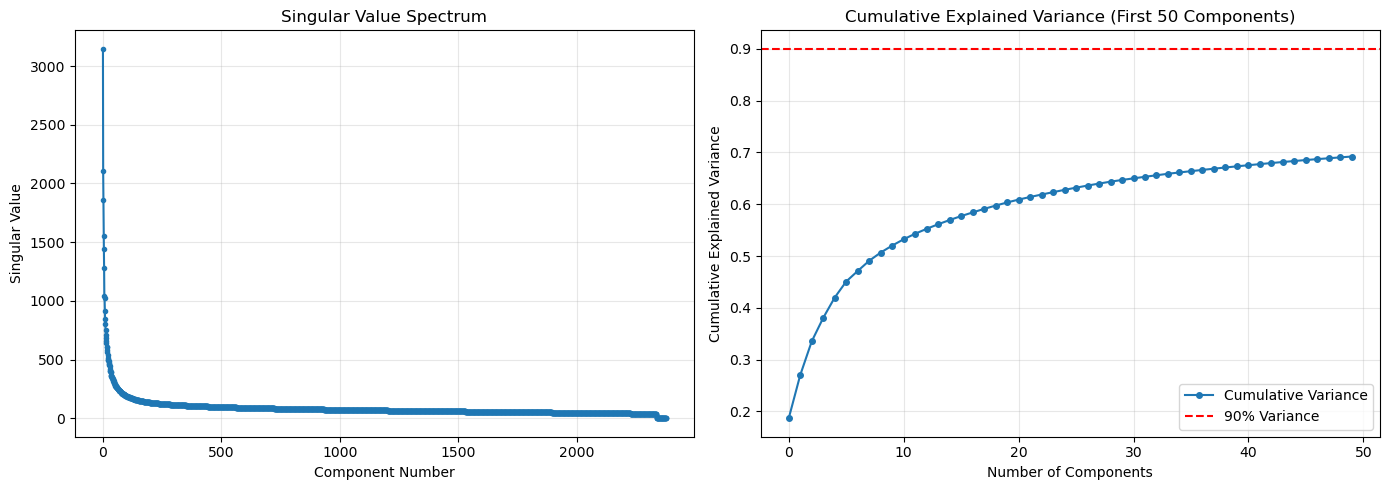

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All singular values
ax1 = axes[0]
ax1.plot(S, marker='o', markersize=3, linewidth=1.5)
ax1.set_xlabel('Component Number')
ax1.set_ylabel('Singular Value')
ax1.set_title('Singular Value Spectrum')
ax1.grid(True, alpha=0.3)

# Plot 2: Explained variance (first 50 components)
ax2 = axes[1]
explained_variance = (S**2) / np.sum(S**2)
cumulative_variance = np.cumsum(explained_variance)
ax2.plot(cumulative_variance[:50], marker='o', markersize=4, linewidth=1.5, label='Cumulative Variance')
ax2.axhline(0.9, color='r', linestyle='--', label='90% Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance (First 50 Components)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svd_singular_values.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'svd_singular_values.png'")
plt.show()

## Step 8: Project Data to 2D (SVD Components)

Reduce the data to the first 2 SVD components for visualization.

Reduced data shape (2 components): (2379, 2)
✓ Plot saved as 'svd_2d_projection.png'


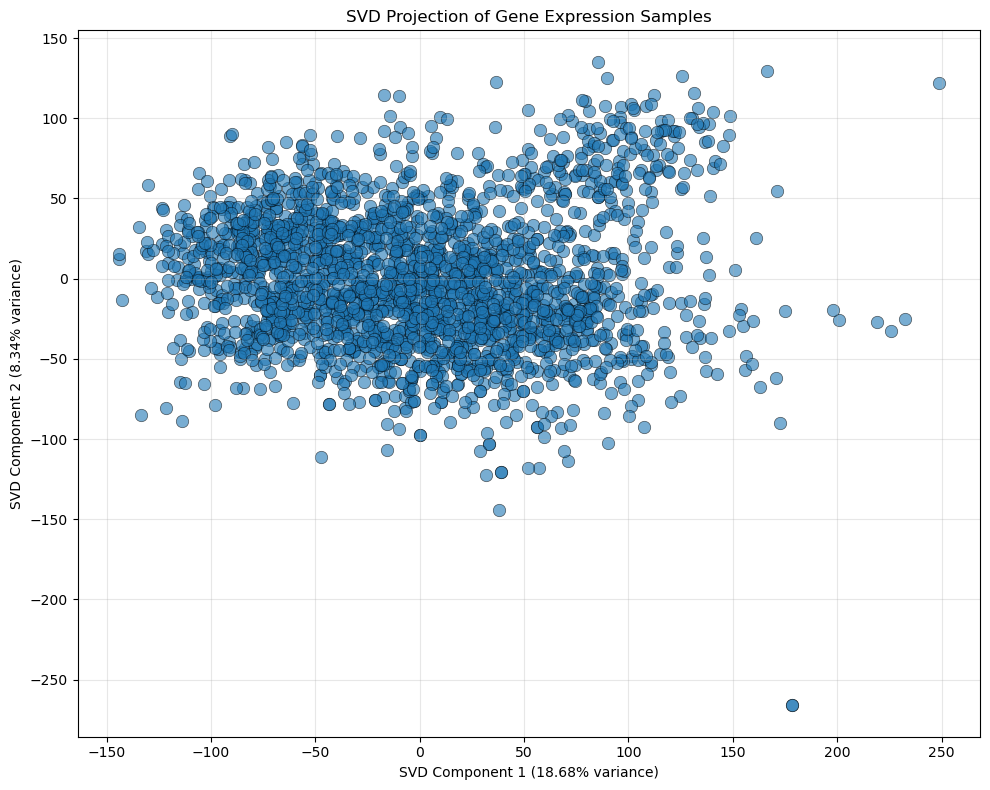

In [8]:
k = 2  # Use first 2 components
X_reduced = U[:, :k] @ np.diag(S[:k])

print(f"Reduced data shape (2 components): {X_reduced.shape}")

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], 
                      alpha=0.6, s=80, edgecolors='k', linewidth=0.5)
ax.set_xlabel(f'SVD Component 1 ({explained_variance[0]*100:.2f}% variance)')
ax.set_ylabel(f'SVD Component 2 ({explained_variance[1]*100:.2f}% variance)')
ax.set_title('SVD Projection of Gene Expression Samples')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svd_2d_projection.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'svd_2d_projection.png'")
plt.show()

## Step 9: Gene Expression Heatmap

Visualize the standardized gene expression values for a subset of the data.

✓ Plot saved as 'gene_expression_heatmap.png'


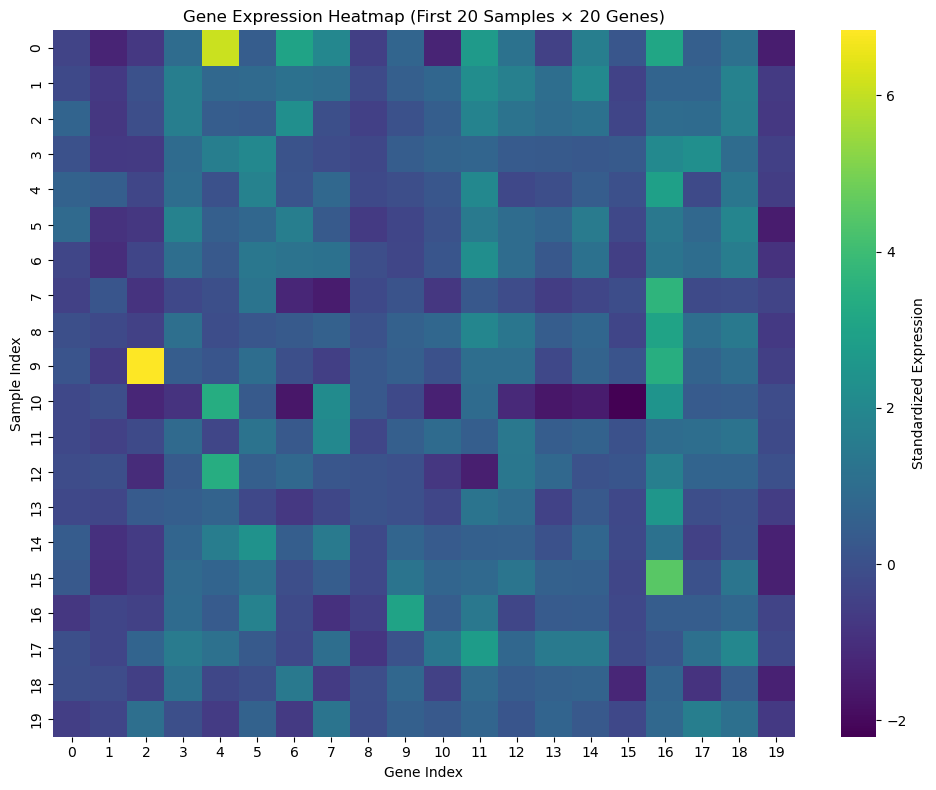

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Show heatmap for first 20 samples and genes
sns.heatmap(X_scaled[:20, :20], cmap='viridis', ax=ax, cbar_kws={'label': 'Standardized Expression'})
ax.set_title('Gene Expression Heatmap (First 20 Samples × 20 Genes)')
ax.set_xlabel('Gene Index')
ax.set_ylabel('Sample Index')

plt.tight_layout()
plt.savefig('gene_expression_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'gene_expression_heatmap.png'")
plt.show()

## Step 10: Identify Top Gene Contributors

Find genes that contribute most to the first SVD component (most informative genes).

In [10]:
# Calculate gene importance based on first component
gene_importance = np.abs(VT[0])
top_gene_indices = np.argsort(gene_importance)[-10:]

top_genes = data.index[top_gene_indices]
top_values = gene_importance[top_gene_indices]

print("\n" + "="*60)
print("Top 10 Genes Contributing to SVD Component 1")
print("="*60)
for i, (gene, val) in enumerate(zip(reversed(top_genes), reversed(sorted(top_values))), 1):
    print(f"{i:2d}. {gene:25s} | Importance: {val:.6f}")


Top 10 Genes Contributing to SVD Component 1
 1. 44702_at                  | Importance: 0.013318
 2. 211157_at                 | Importance: 0.013308
 3. 39763_at                  | Importance: 0.013305
 4. 32811_at                  | Importance: 0.013287
 5. 33768_at                  | Importance: 0.013212
 6. 222185_at                 | Importance: 0.013095
 7. 41856_at                  | Importance: 0.013080
 8. 32094_at                  | Importance: 0.013033
 9. 211295_x_at               | Importance: 0.013031
10. 222271_at                 | Importance: 0.012986


## Step 11: Visualize Top Gene Contributions

Bar plot showing the importance of top genes in SVD components.

✓ Plot saved as 'top_genes_contributions.png'


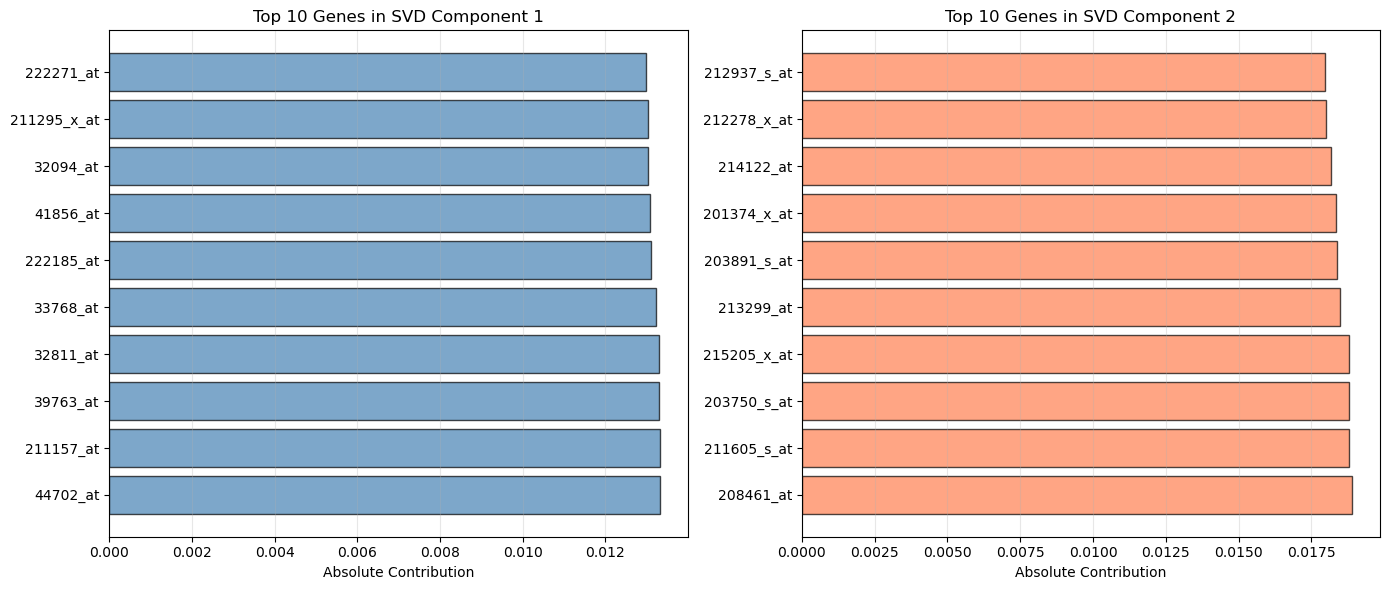

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Top genes in Component 1
ax1 = axes[0]
top_indices_comp1 = np.argsort(np.abs(VT[0]))[-10:]
top_genes_comp1 = [data.index[i] for i in top_indices_comp1]
top_values_comp1 = np.abs(VT[0][top_indices_comp1])

ax1.barh(range(len(top_genes_comp1)), top_values_comp1, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top_genes_comp1)))
ax1.set_yticklabels(top_genes_comp1)
ax1.set_xlabel('Absolute Contribution')
ax1.set_title('Top 10 Genes in SVD Component 1')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Top genes in Component 2
ax2 = axes[1]
top_indices_comp2 = np.argsort(np.abs(VT[1]))[-10:]
top_genes_comp2 = [data.index[i] for i in top_indices_comp2]
top_values_comp2 = np.abs(VT[1][top_indices_comp2])

ax2.barh(range(len(top_genes_comp2)), top_values_comp2, color='coral', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(top_genes_comp2)))
ax2.set_yticklabels(top_genes_comp2)
ax2.set_xlabel('Absolute Contribution')
ax2.set_title('Top 10 Genes in SVD Component 2')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('top_genes_contributions.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'top_genes_contributions.png'")
plt.show()

## Step 12: Summary Statistics

Print comprehensive summary of the SVD analysis.

In [12]:
print("\n" + "="*60)
print("SVD ANALYSIS SUMMARY")
print("="*60)

print(f"\nInput Data:")
print(f"  Samples: {X.shape[0]}")
print(f"  Genes: {X.shape[1]:,}")

print(f"\nSVD Components:")
print(f"  Total components: {len(S)}")
print(f"  Max singular value: {S[0]:.4f}")
print(f"  Min singular value: {S[-1]:.4f}")

print(f"\nVariance Explained:")
print(f"  First 2 components: {sum(explained_variance[:2])*100:.2f}%")
print(f"  First 5 components: {sum(explained_variance[:5])*100:.2f}%")
print(f"  First 10 components: {sum(explained_variance[:10])*100:.2f}%")

n_comp_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"  Components for 90% variance: {n_comp_90}")

print(f"\n✓ SVD-based gene expression analysis completed successfully!")
print("="*60)


SVD ANALYSIS SUMMARY

Input Data:
  Samples: 2379
  Genes: 22,283

SVD Components:
  Total components: 2379
  Max singular value: 3146.7604
  Min singular value: 0.0000

Variance Explained:
  First 2 components: 27.02%
  First 5 components: 41.98%
  First 10 components: 52.01%
  Components for 90% variance: 790

✓ SVD-based gene expression analysis completed successfully!
